In [ ]:
#Install Package
!pip install yfinance
!pip install yahoofinancials


In [ ]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
from IPython.display import display

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))

sp500_table = None
for table in tables:
    cols_lower = [str(c).lower() for c in table.columns]
    if "symbol" in cols_lower:
        sp500_table = table.copy()
        break

if sp500_table is None:
    raise ValueError("No table with a 'Symbol' column found on the page.")

for col in sp500_table.columns:
    if str(col).lower() == "symbol":
        symbol_col = col
        break

sp500_table.rename(columns={symbol_col: "Symbol"}, inplace=True)

sp500_table["Symbol"] = (
    sp500_table["Symbol"]
    .astype(str)
    .str.replace(".", "-", regex=False)
)

tickers = sp500_table["Symbol"].unique().tolist()

print("Number of tickers:", len(tickers))
display(sp500_table.head())

hist = yf.download(tickers=tickers, start='2022-01-01', end='2025-01-01', interval='1d', actions=False)


Number of tickers: 503


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


/tmp/ipykernel_4210/1775929807.py:43: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hist = yf.download(tickers=tickers, start='2022-01-01', end='2025-01-01', interval='1d', actions=False)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')


In [ ]:
hist

Price      Adj Close            Close                                      \
Ticker             Q SNDK           A        AAPL        ABBV        ABNB   
Date                                                                        
2022-01-03       NaN  NaN  151.702148  178.103668  114.894043  172.679993   
2022-01-04       NaN  NaN  146.573685  175.843231  114.673462  170.800003   
2022-01-05       NaN  NaN  144.062744  171.165787  115.275818  162.250000   
2022-01-06       NaN  NaN  144.566849  168.308533  114.732872  159.750000   
2022-01-07       NaN  NaN  140.718079  168.474854  114.435898  166.050003   
...              ...  ...         ...         ...         ...         ...   
2024-12-24       NaN  NaN  134.457260  256.797211  171.111115  134.990005   
2024-12-26       NaN  NaN  134.190506  257.612732  170.350616  135.320007   
2024-12-27       NaN  NaN  133.904007  254.201385  169.219391  133.384995   
2024-12-30       NaN  NaN  132.797546  250.829803  167.498749  131.809998   
2024-12-31       NaN  NaN  132.963821  249.059464  168.924683  131.410004   

Price                                                      ...   Volume  \
Ticker             ABT       ACGL         ACN        ADBE  ...       WY   
Date                                                       ...            
2022-01-03  127.545822  42.362530  380.485291  564.369995  ...  3831100   
2022-01-04  124.546143  42.914051  377.766296  554.000000  ...  3089700   
2022-01-05  123.986565  42.410072  371.113495  514.429993  ...  3737600   
2022-01-06  123.968254  42.657307  353.192352  514.119995  ...  3315200   
2022-01-07  124.353500  42.856995  346.418091  510.700012  ...  3309900   
...                ...        ...         ...         ...  ...      ...   
2024-12-24  111.359657  92.669998  353.541504  447.940002  ...  1780100   
2024-12-26  111.854553  92.930000  352.368317  450.160004  ...  1736500   
2024-12-27  111.582840  92.339996  348.213348  446.480011  ...  2320500   
2024-12-30  109.457741  91.889999  344.605896  445.799988  ...  2914700   
2024-12-31  109.758545  92.349998  343.921600  444.679993  ...  3125200   

Price                                                                        \
Ticker         WYNN      XEL       XOM      XYL       XYZ      YUM      ZBH   
Date                                                                          
2022-01-03  2437800  3501100  24282400   759100   7315700  1251400  1184809   
2022-01-04  2292300  4197000  38584000   925400  14768500   935900  1400800   
2022-01-05  3439900  4166000  34033300  1090200  17546200   977900  1895715   
2022-01-06  2583200  2296000  30668500   703400  16244200   862400  1088813   
2022-01-07  1720400  2673100  23985400   765000   9426000   833700  1690230   
...             ...      ...       ...      ...       ...      ...      ...   
2024-12-24   692800   943900   7807000   379300   2197700   533000   458600   
2024-12-26  1218900  1394900   9652400   575700   2991100  1040900  1277300   
2024-12-27  1086700  2015000  11943900   552400   4140800  1146300   743400   
2024-12-30  2180100  2642900  11080800   586800   5383800  1144600  1532000   
2024-12-31  1612600  2143800  12387800   641600   4989400  1217100   683300   

Price                        
Ticker        ZBRA      ZTS  
Date                         
2022-01-03  272600  2772700  
2022-01-04  346000  4664000  
2022-01-05  403700  4749400  
2022-01-06  338300  3103400  
2022-01-07  432800  2206500  
...            ...      ...  
2024-12-24   88700  1023600  
2024-12-26  140100  2167200  
2024-12-27  287200  1800100  
2024-12-30  211300  1531400  
2024-12-31  327900  1327400  

[753 rows x 2517 columns]

In [ ]:
hist = hist.drop('Q', axis=1, level=1)
hist = hist.drop('SNDK', axis=1, level=1)
hist = hist.drop('GEV', axis=1, level=1)
hist = hist.drop('SOLV', axis=1, level=1)
hist = hist.drop('VLTO', axis=1, level=1)
hist = hist.drop('KVUE', axis=1, level=1)
hist = hist.drop('GEHC', axis=1, level=1)
hist = hist.bfill()
hist

Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  151.702148  178.103668  114.894043  172.679993  127.545822   
2022-01-04  146.573685  175.843231  114.673462  170.800003  124.546143   
2022-01-05  144.062744  171.165787  115.275818  162.250000  123.986565   
2022-01-06  144.566849  168.308533  114.732872  159.750000  123.968254   
2022-01-07  140.718079  168.474854  114.435898  166.050003  124.353500   
...                ...         ...         ...         ...         ...   
2024-12-24  134.457260  256.797211  171.111115  134.990005  111.359657   
2024-12-26  134.190506  257.612732  170.350616  135.320007  111.854553   
2024-12-27  133.904007  254.201385  169.219391  133.384995  111.582840   
2024-12-30  132.797546  250.829803  167.498749  131.809998  109.457741   
2024-12-31  132.963821  249.059464  168.924683  131.410004  109.758545   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  380.485291  564.369995  164.526459  60.037262  ...   
2022-01-04  42.914051  377.766296  554.000000  163.040497  61.151524  ...   
2022-01-05  42.410072  371.113495  514.429993  160.523605  60.673973  ...   
2022-01-06  42.657307  353.192352  514.119995  161.034409  61.213425  ...   
2022-01-07  42.856995  346.418091  510.700012  156.808609  61.735180  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  353.541504  447.940002  213.882034  48.364082  ...   
2024-12-26  92.930000  352.368317  450.160004  213.852631  48.344975  ...   
2024-12-27  92.339996  348.213348  446.480011  212.803284  48.316326  ...   
2024-12-30  91.889999  344.605896  445.799988  208.458755  47.829140  ...   
2024-12-31  92.349998  343.921600  444.679993  208.360703  48.259007  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[753 rows x 2480 columns]

In [ ]:
import numpy as np

data = hist['Close']

daily_returns = data.pct_change()

daily_returns

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.033806,-0.012692,-0.001920,-0.010887,-0.023518,0.013019,-0.007146,-0.018374,-0.009032,0.018560,...,0.012817,-0.003190,0.006329,0.037614,0.010608,-0.046943,0.005347,0.010145,0.006337,-0.038072
2022-01-05,-0.017131,-0.026600,0.005253,-0.050059,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,...,-0.024824,-0.037033,0.009800,0.012437,-0.013629,-0.082134,-0.012677,-0.003296,-0.050068,-0.038024
2022-01-06,0.003499,-0.016693,-0.004710,-0.015408,-0.000148,0.005830,-0.048290,-0.000603,0.003182,0.008891,...,0.007986,0.004629,-0.007822,0.023521,-0.001373,0.008154,0.010330,-0.008307,-0.005410,0.003971
2022-01-07,-0.026623,0.000988,-0.002588,0.039437,0.003108,0.004681,-0.019180,-0.006652,-0.026242,0.008524,...,-0.001237,-0.001063,0.008759,0.008197,-0.007992,-0.021568,-0.011466,-0.006050,-0.043771,-0.029114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011144,0.011478,0.009025,0.003494,0.003937,0.006298,0.007972,0.002686,0.014891,0.004364,...,0.006410,0.007604,0.007236,0.000941,0.005446,0.020047,0.008516,0.004494,0.012262,0.002557
2024-12-26,-0.001984,0.003176,-0.004444,0.002445,0.004444,0.002806,-0.003318,0.004956,-0.000137,-0.000395,...,-0.003185,0.005970,-0.000440,0.000846,0.002708,0.004392,0.007407,-0.000466,0.003566,0.004979
2024-12-27,-0.002135,-0.013242,-0.006641,-0.014300,-0.002429,-0.006349,-0.011792,-0.008175,-0.004907,-0.000593,...,-0.006390,-0.007054,-0.000587,-0.000094,-0.007934,-0.027438,-0.005662,-0.003543,-0.019604,-0.005558


In [ ]:
def fetch_data(tickers, index='^GSPC', start='2022-01-01', end='2025-01-01', interval='1d'):
    all_tickers = tickers + [index]
    df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
    return df


def calculate_ratios(returns, benchmark_returns, risk_free_rate=0.04/252):
    excess = returns - risk_free_rate
    downside = excess[excess < 0]

    beta = np.cov(returns, benchmark_returns)[0,1] / np.var(benchmark_returns)
    return beta


def build_screener(tickers, index='^GSPC', start='2022-01-01',end='2025-01-01', risk_free_rate=0.04/252):
    df = fetch_data(tickers, index=index, start=start, end=end)
    benchmark = df[index].pct_change().dropna()
    results = []

    for ticker in tickers:
        ret = df[ticker].pct_change().dropna()
        aligned = pd.concat([ret, benchmark], axis=1, join='inner').dropna()
        beta = calculate_ratios(aligned[ticker], aligned[index], risk_free_rate)
        results.append({'Ticker': ticker, 'Beta': beta})

    return pd.DataFrame(results).sort_values('Beta', ascending=False)

In [ ]:
df = build_screener(tickers, index='^GSPC', start ='2022-01-01', end='2025-01-01')
df

/tmp/ipykernel_4210/1603783966.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
[*********************100%***********************]  504 of 504 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
/tmp/ipykernel_4210/1603783966.py:21: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = df[ticker].pct_change().dropna()
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local

,Ticker,Beta
88,CVNA,3.298454
118,COIN,2.964902
67,XYZ,2.548173
344,NVDA,2.271536
40,APP,2.264945
...,...,...
414,SJM,0.196851
83,CPB,0.133843
219,GIS,0.133426
386,Q,NaN


In [ ]:
annual_volatility = daily_returns.std() * np.sqrt(252)
annual_volatility

,0
Ticker,
A,0.296259
AAPL,0.270935
ABBV,0.219958
ABNB,0.467875
ABT,0.217839
...,...
XYZ,0.653825
YUM,0.191335
ZBH,0.245157


In [ ]:
mean_daily_return = daily_returns.mean()

volatility_df = annual_volatility.reset_index()
volatility_df.columns = ['Ticker', 'Annual Volatility']

daily_return_df = mean_daily_return.reset_index()
daily_return_df.columns = ['Ticker', 'Daily Return']

merged_df = df.merge(volatility_df, on='Ticker').merge(daily_return_df, on='Ticker')

merged_df.head()

,Ticker,Beta,Annual Volatility,Daily Return
0,CVNA,3.298454,1.341039,0.003219
1,COIN,2.964902,0.953848,0.001768
2,XYZ,2.548173,0.653825,-0.000034
3,NVDA,2.271536,0.552710,0.002588
4,APP,2.264945,0.788374,0.002802


In [ ]:
def classify_stock(row):
    beta = row["Beta"]
    volatility = row["Annual Volatility"]
    return_daily = row["Daily Return"]

    if beta < 0.9 and return_daily > 0.01:
        return "Safe, High profit"

    elif beta < 0.9 and return_daily > 0:
        return "Low Risk, Low profit"

    elif beta < 0.9:
        return "Low Risk"

    elif 0.9 <= beta <= 1.1:
        return "Moderate"

    else:
        return "High Risk"

merged_df["Portfolio"] = merged_df.apply(classify_stock, axis=1)
merged_df

,Ticker,Beta,Annual Volatility,Daily Return,Portfolio
0,CVNA,3.298454,1.341039,0.003219,High Risk
1,COIN,2.964902,0.953848,0.001768,High Risk
2,XYZ,2.548173,0.653825,-0.000034,High Risk
3,NVDA,2.271536,0.552710,0.002588,High Risk
4,APP,2.264945,0.788374,0.002802,High Risk
...,...,...,...,...,...
491,LMT,0.244190,0.209530,0.000611,"Low Risk, Low profit"
492,HRL,0.236922,0.232603,-0.000376,Low Risk
493,SJM,0.196851,0.219994,-0.000065,Low Risk
494,CPB,0.133843,0.223119,0.000168,"Low Risk, Low profit"


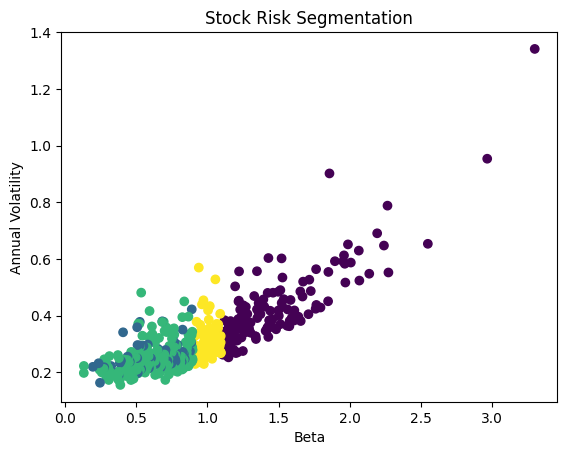

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(merged_df["Beta"], merged_df["Annual Volatility"],
            c=merged_df["Portfolio"].astype("category").cat.codes)

plt.xlabel("Beta")
plt.ylabel("Annual Volatility")
plt.title("Stock Risk Segmentation")
plt.show()

In [ ]:
merged_df

,Ticker,Beta,Annual Volatility,Daily Return,Portfolio
0,CVNA,3.298454,1.341039,0.003219,High Risk
1,COIN,2.964902,0.953848,0.001768,High Risk
2,XYZ,2.548173,0.653825,-0.000034,High Risk
3,NVDA,2.271536,0.552710,0.002588,High Risk
4,APP,2.264945,0.788374,0.002802,High Risk
...,...,...,...,...,...
491,LMT,0.244190,0.209530,0.000611,"Low Risk, Low profit"
492,HRL,0.236922,0.232603,-0.000376,Low Risk
493,SJM,0.196851,0.219994,-0.000065,Low Risk
494,CPB,0.133843,0.223119,0.000168,"Low Risk, Low profit"


Part B

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score

features = ['Beta', 'Annual Volatility', 'Daily Return']
X = merged_df[features].copy()
print("Feature shape:", X.shape, "NaN check:", X.isna().sum().sum())
X.describe().round(4)

Feature shape: (496, 3) NaN check: 0


,Beta,Annual Volatility,Daily Return
count,496.0000,496.0000,496.0000
mean,0.9450,0.3143,0.0004
std,0.4324,0.1148,0.0007
min,0.1334,0.1562,-0.0017
25%,0.6338,0.2401,0.0000
50%,0.9129,0.2850,0.0004
75%,1.1572,0.3573,0.0008
max,3.2985,1.3410,0.0041


Skewness of raw features:
  Beta                  : +1.095
  Annual Volatility     : +2.853
  Daily Return          : +0.987


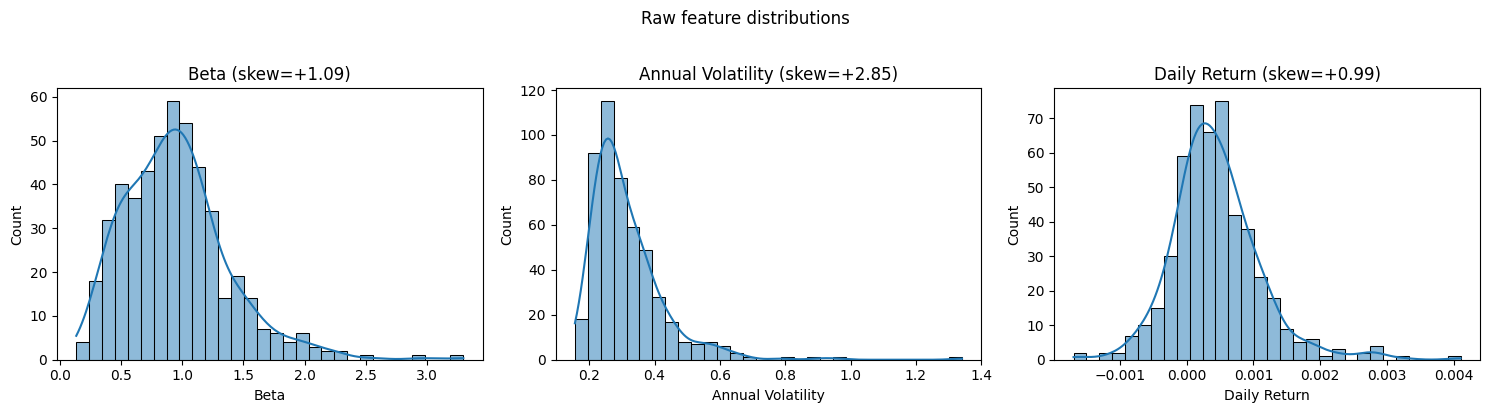

In [ ]:
print("Skewness of raw features:")
for c in features:
    print(f"  {c:22s}: {stats.skew(X[c]):+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, features):
    sns.histplot(data=X, x=col, kde=True, ax=ax, bins=30)
    ax.set_title(f'{col} (skew={stats.skew(X[col]):+.2f})')
plt.suptitle('Raw feature distributions', y=1.02)
plt.tight_layout(); plt.show()

Skewness after Box-Cox:
  Beta                  : +0.009
  Annual Volatility     : +0.026
  Daily Return          : +0.987

Post-scaling sanity check:
  means: [-0.  0.  0.]
  stds:  [1. 1. 1.]


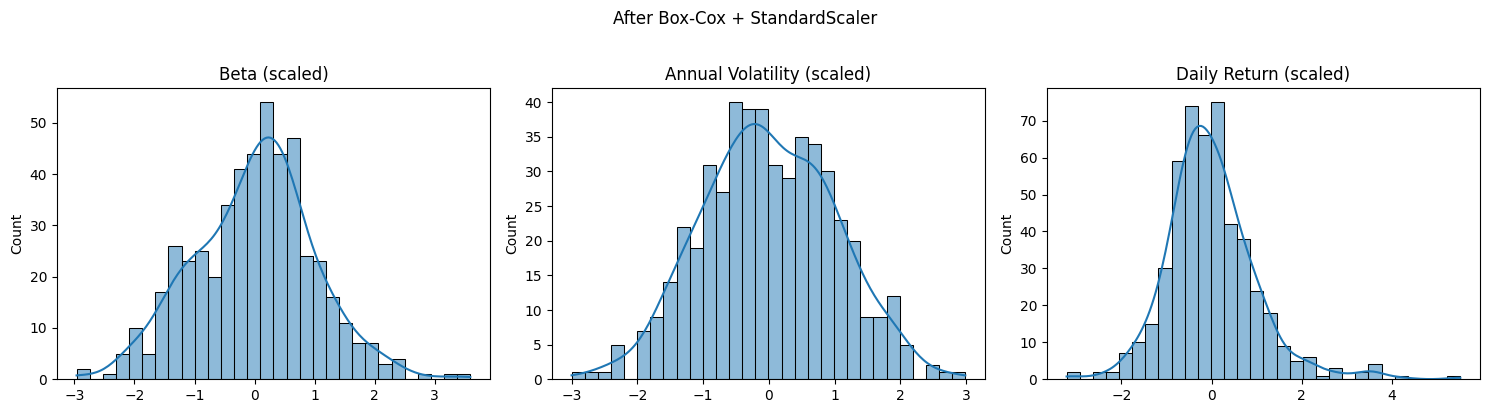

In [ ]:
X_fix = pd.DataFrame(index=X.index)

beta_min = X['Beta'].min()
shift_beta = 0 if beta_min > 0 else (1 - beta_min)
X_fix['Beta'] = stats.boxcox(X['Beta'] + shift_beta)[0]

vol_min = X['Annual Volatility'].min()
shift_vol = 0 if vol_min > 0 else (1 - vol_min)
X_fix['Annual Volatility'] = stats.boxcox(X['Annual Volatility'] + shift_vol)[0]

X_fix['Daily Return'] = X['Daily Return'].values

print("Skewness after Box-Cox:")
for c in features:
    print(f"  {c:22s}: {stats.skew(X_fix[c]):+.3f}")


scaler = StandardScaler()
scaler.fit(X_fix)
X_scaled = scaler.transform(X_fix)
print("\nPost-scaling sanity check:")
print("  means:", np.round(X_scaled.mean(axis=0), 2))
print("  stds: ", np.round(X_scaled.std(axis=0), 2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, col) in enumerate(zip(axes, features)):
    sns.histplot(X_scaled[:, i], kde=True, ax=ax, bins=30)
    ax.set_title(f'{col} (scaled)')
plt.suptitle('After Box-Cox + StandardScaler', y=1.02)
plt.tight_layout(); plt.show()

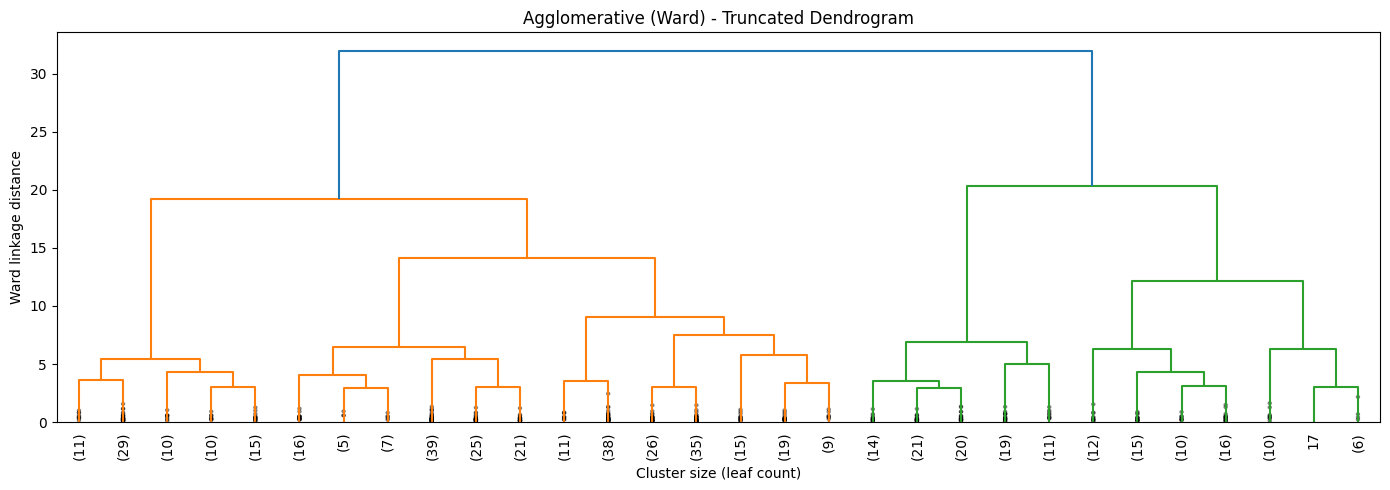

In [ ]:

Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90.,
           leaf_font_size=10, show_contracted=True)
plt.title('Agglomerative (Ward) - Truncated Dendrogram')
plt.xlabel('Cluster size (leaf count)')
plt.ylabel('Ward linkage distance')
plt.tight_layout(); plt.show()

Silhouette scores: [np.float64(0.3445), np.float64(0.295), np.float64(0.2684), np.float64(0.273), np.float64(0.2758), np.float64(0.2587), np.float64(0.2308), np.float64(0.2275)]
Average: 0.2717


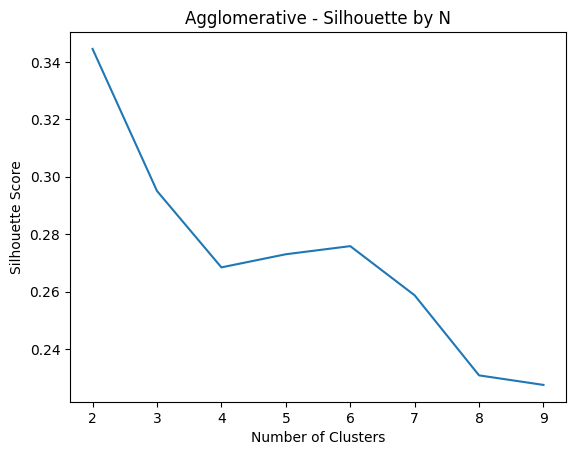

Highest silhouette at N = 2


In [ ]:

range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for n_clusters in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    agglom.fit(X_scaled)
    labels = agglom.labels_
    scores.append(silhouette_score(X_scaled, labels))

average = sum(scores) / len(scores)
print(f"Silhouette scores: {[round(s, 4) for s in scores]}")
print(f"Average: {average:.4f}")

plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Agglomerative - Silhouette by N')
plt.show()

best_N = range_n_clusters[int(np.argmax(scores))]
print(f"Highest silhouette at N = {best_N}")

Cluster 1 has 155 observations
Cluster 2 has 341 observations


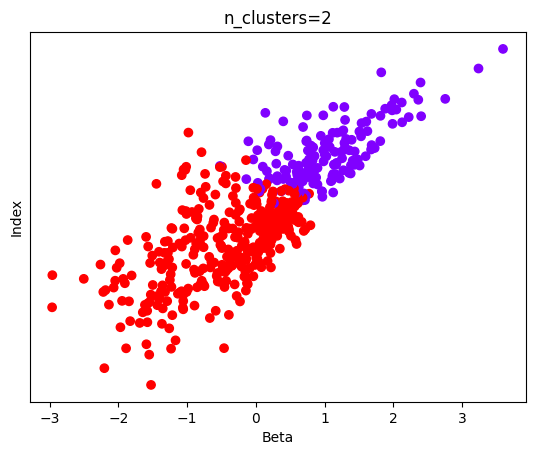

Cluster 1 has 341 observations
Cluster 2 has 70 observations
Cluster 3 has 85 observations


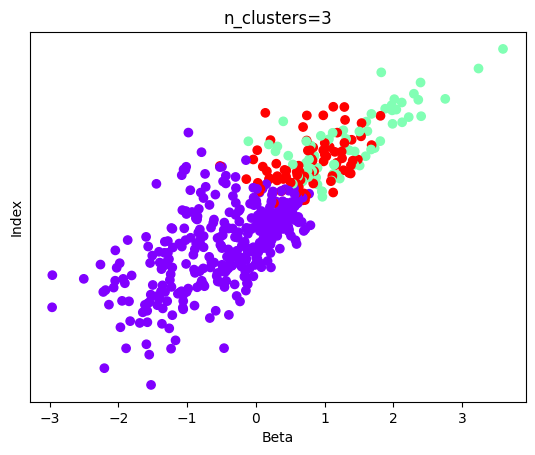

Cluster 1 has 266 observations
Cluster 2 has 70 observations
Cluster 3 has 85 observations
Cluster 4 has 75 observations


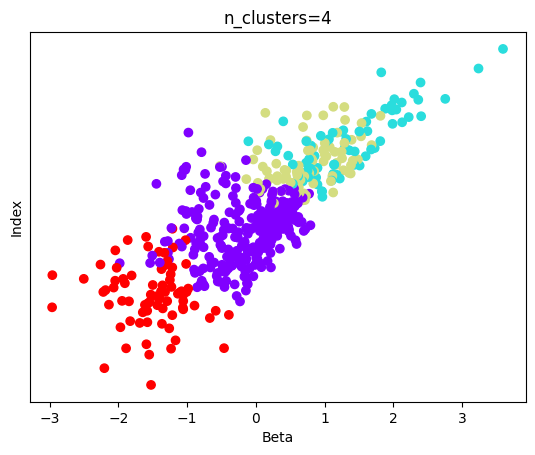

Cluster 1 has 70 observations
Cluster 2 has 153 observations
Cluster 3 has 85 observations
Cluster 4 has 75 observations
Cluster 5 has 113 observations


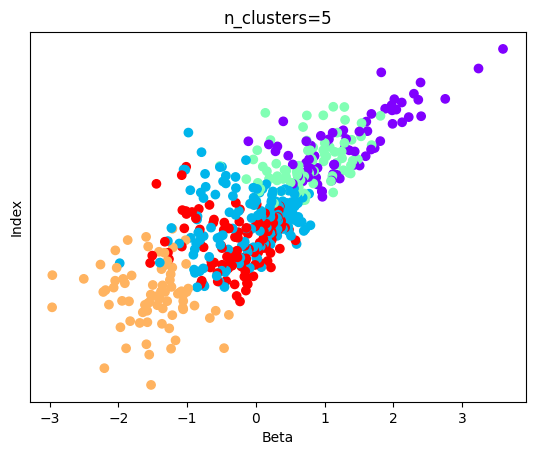

Cluster 1 has 153 observations
Cluster 2 has 113 observations
Cluster 3 has 85 observations
Cluster 4 has 75 observations
Cluster 5 has 17 observations
Cluster 6 has 53 observations


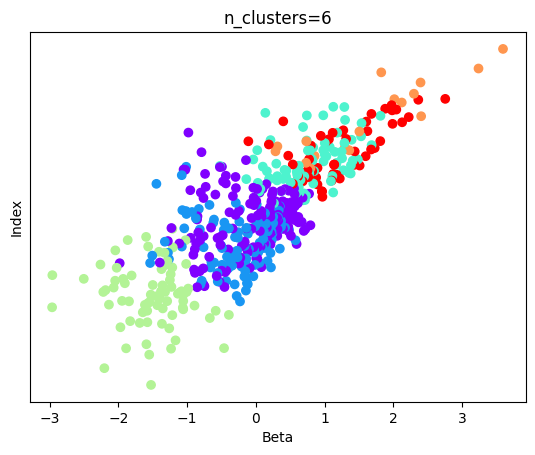

Cluster 1 has 104 observations
Cluster 2 has 113 observations
Cluster 3 has 85 observations
Cluster 4 has 75 observations
Cluster 5 has 17 observations
Cluster 6 has 53 observations
Cluster 7 has 49 observations


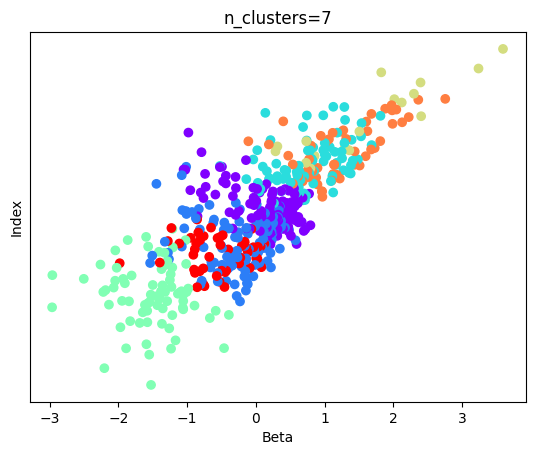

Cluster 1 has 85 observations
Cluster 2 has 113 observations
Cluster 3 has 53 observations
Cluster 4 has 75 observations
Cluster 5 has 17 observations
Cluster 6 has 43 observations
Cluster 7 has 49 observations
Cluster 8 has 61 observations


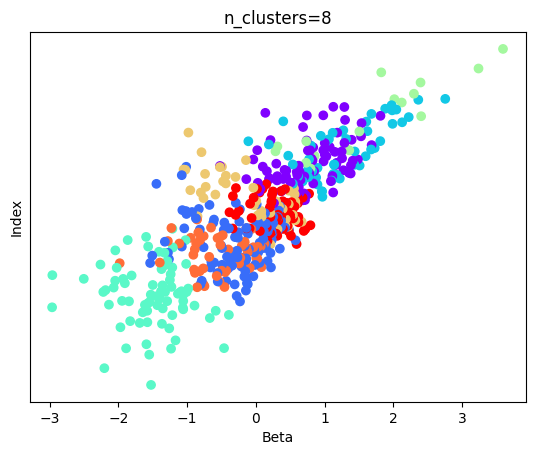

Cluster 1 has 113 observations
Cluster 2 has 17 observations
Cluster 3 has 53 observations
Cluster 4 has 75 observations
Cluster 5 has 30 observations
Cluster 6 has 43 observations
Cluster 7 has 49 observations
Cluster 8 has 61 observations
Cluster 9 has 55 observations


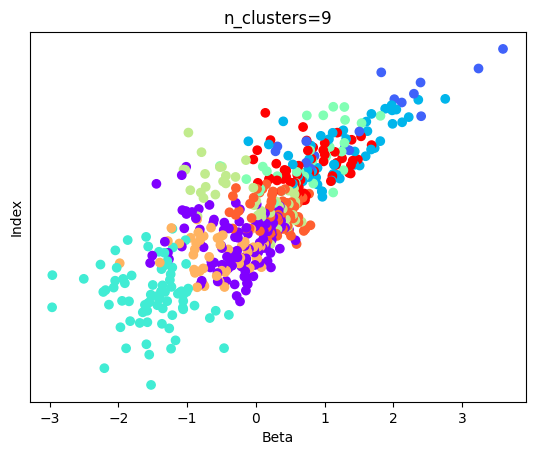

In [ ]:
import numpy as np
for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X_scaled)
    # Create scatter plot of data points colored by cluster label
    plt.scatter(X_scaled[:, 0], X_scaled[:,1], c=labels, cmap='rainbow')
    plt.xlabel('Beta')
    plt.ylabel('Index')
    plt.title(f"n_clusters={n_clusters}")
    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
      print(f"Cluster {i+1} has {cluster_counts[i]} observations")
    plt.yticks([])
    plt.show()

In [ ]:

optimal_n_clusters = best_N
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
merged_df['Agg_Cluster'] = agglom.fit_predict(X_scaled)

print(f"Agglomerative (N={optimal_n_clusters}) cluster sizes:")
print(merged_df['Agg_Cluster'].value_counts().sort_index())
print("\nCluster profile (original units, interpretable for investors):")
merged_df.groupby('Agg_Cluster')[features].agg(['mean', 'count']).round(4)

Agglomerative (N=2) cluster sizes:
Agg_Cluster
0    155
1    341
Name: count, dtype: int64

Cluster profile (original units, interpretable for investors):


Beta       Annual Volatility       Daily Return      
               mean count              mean count         mean count
Agg_Cluster                                                         
0            1.3981   155            0.4338   155       0.0005   155
1            0.7390   341            0.2600   341       0.0004   341

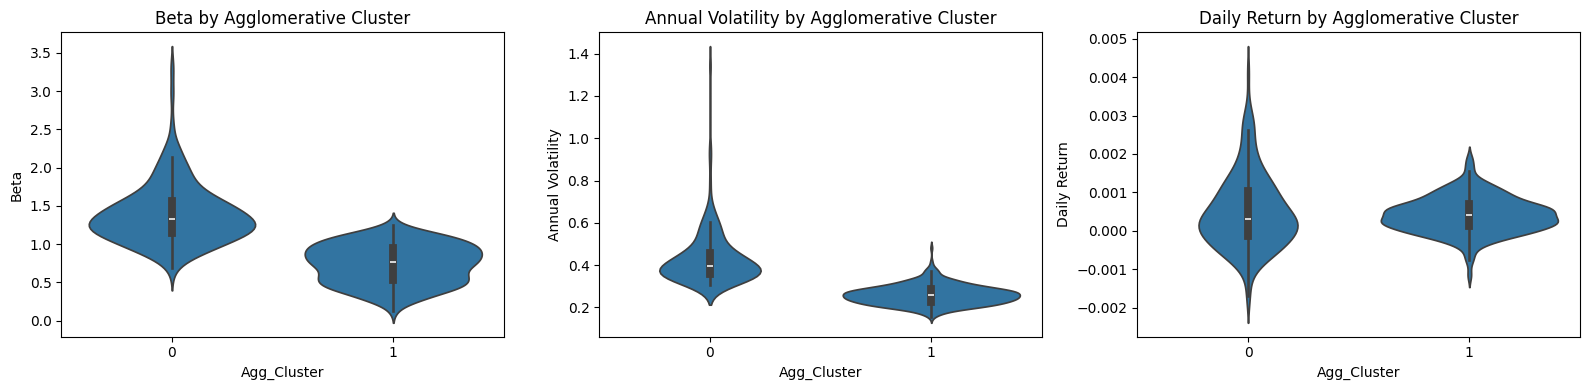

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, features):
    sns.violinplot(x='Agg_Cluster', y=col, data=merged_df, ax=ax)
    ax.set_title(f'{col} by Agglomerative Cluster')
plt.tight_layout(); plt.show()

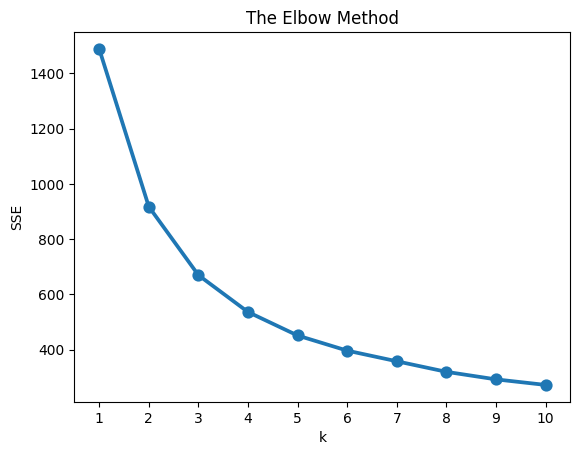

Inertia per K: {1: 1488.0, 2: 917.3, 3: 669.5, 4: 536.2, 5: 451.2, 6: 396.4, 7: 357.9, 8: 319.7, 9: 292.4, 10: 272.3}


In [ ]:

sse = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse[k] = km.inertia_

plt.title('The Elbow Method')
plt.xlabel('k'); plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()
print("Inertia per K:", {k: round(v, 1) for k, v in sse.items()})

best_K = 4

In [ ]:
K_FINAL = best_K
model = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
model.fit(X_scaled)
merged_df['KMeans_Cluster'] = model.labels_

print(f"K-Means (K={K_FINAL}) cluster sizes:")
print(merged_df['KMeans_Cluster'].value_counts().sort_index())

print("\nCluster profile (original units):")
merged_df.groupby('KMeans_Cluster').agg({
    'Beta': 'mean',
    'Annual Volatility': 'mean',
    'Daily Return': ['mean', 'count']
}).round(4)

K-Means (K=4) cluster sizes:
KMeans_Cluster
0    119
1    212
2     58
3    107
Name: count, dtype: int64

Cluster profile (original units):


Beta Annual Volatility Daily Return      
                  mean              mean         mean count
KMeans_Cluster                                             
0               0.4772            0.2176       0.0004   119
1               0.8785            0.2818       0.0004   212
2               1.5432            0.4857       0.0016    58
3               1.2725            0.3934      -0.0001   107

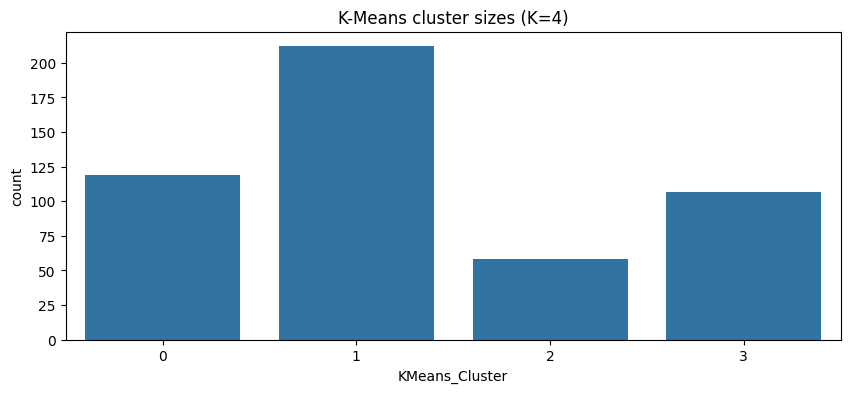

In [ ]:
plt.figure(figsize=(10, 4))
sns.countplot(x='KMeans_Cluster', data=merged_df)
plt.title(f'K-Means cluster sizes (K={K_FINAL})')
plt.show()

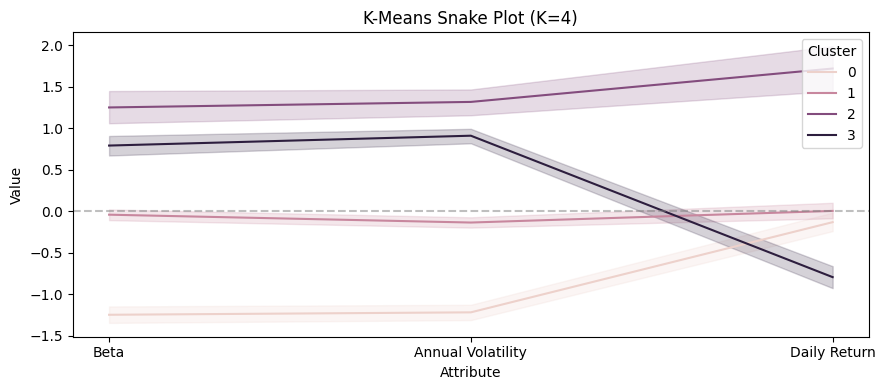

In [ ]:
# Snake plot: standardised mean of each feature per cluster.
# Useful for the report - each line = one cluster's "risk-return shape".
df_normalized = pd.DataFrame(X_scaled, columns=features)
df_normalized['ID'] = merged_df['Ticker'].values
df_normalized['Cluster'] = model.labels_

df_nor_melt = pd.melt(df_normalized.reset_index(),
                      id_vars=['ID', 'Cluster'],
                      value_vars=features,
                      var_name='Attribute',
                      value_name='Value')
plt.figure(figsize=(9, 4))
sns.lineplot(data=df_nor_melt, x='Attribute', y='Value', hue='Cluster')
plt.axhline(0, ls='--', color='gray', alpha=0.5)
plt.title(f'K-Means Snake Plot (K={K_FINAL})')
plt.tight_layout(); plt.show()

In [ ]:
merged_df.to_csv('features_with_clusters.csv', index=False)
print("Saved features_with_clusters.csv with shape:", merged_df.shape)
print("Columns:", merged_df.columns.tolist())

Saved features_with_clusters.csv with shape: (496, 7)
Columns: ['Ticker', 'Beta', 'Annual Volatility', 'Daily Return', 'Portfolio', 'Agg_Cluster', 'KMeans_Cluster']


Part C


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


merged_df = pd.read_csv('features_with_clusters.csv')
merged_df.head()

,Ticker,Beta,Annual Volatility,Daily Return,Portfolio,Agg_Cluster,KMeans_Cluster
0,CVNA,3.298454,1.341039,0.003219,High Risk,0,2
1,COIN,2.964902,0.953848,0.001768,High Risk,0,2
2,XYZ,2.548173,0.653825,-0.000034,High Risk,0,3
3,NVDA,2.271536,0.552710,0.002588,High Risk,0,2
4,APP,2.264945,0.788374,0.002802,High Risk,0,2


In [ ]:
merged_df.shape


(496, 7)

In [ ]:
merged_df.groupby('KMeans_Cluster').agg({
    'Beta':'mean',
    'Annual Volatility':'mean',
    'Daily Return':['mean', 'count']}).round(4)

Beta Annual Volatility Daily Return      
                  mean              mean         mean count
KMeans_Cluster                                             
0               0.4772            0.2176       0.0004   119
1               0.8785            0.2818       0.0004   212
2               1.5432            0.4857       0.0016    58
3               1.2725            0.3934      -0.0001   107

In [ ]:
profile = merged_df.groupby('KMeans_Cluster')[['Beta', 'Annual Volatility', 'Daily Return']].mean()
profile['RiskScore'] = profile['Beta'] + profile['Annual Volatility']
profile_sorted = profile.sort_values('RiskScore')
profile_sorted

,Beta,Annual Volatility,Daily Return,RiskScore
KMeans_Cluster,,,,
0,0.477223,0.217614,0.000354,0.694838
1,0.878528,0.281771,0.000443,1.160299
3,1.272540,0.393354,-0.000086,1.665894
2,1.543203,0.485729,0.001581,2.028932


In [ ]:
def cluster_name(row):
    cid = row['KMeans_Cluster']
    rank = list(profile_sorted.index).index(cid)
    if rank == 0:
        return 'Defensive'
    elif rank == 1:
        return 'Core Market'
    elif rank == 2:
        return 'High-Beta Growth'
    else:
        return 'Speculative'

merged_df['ClusterName'] = merged_df.apply(cluster_name, axis=1)
merged_df.head()

,Ticker,Beta,Annual Volatility,Daily Return,Portfolio,Agg_Cluster,KMeans_Cluster,ClusterName
0,CVNA,3.298454,1.341039,0.003219,High Risk,0,2,Speculative
1,COIN,2.964902,0.953848,0.001768,High Risk,0,2,Speculative
2,XYZ,2.548173,0.653825,-0.000034,High Risk,0,3,High-Beta Growth
3,NVDA,2.271536,0.552710,0.002588,High Risk,0,2,Speculative
4,APP,2.264945,0.788374,0.002802,High Risk,0,2,Speculative


In [ ]:
pd.crosstab(merged_df['Portfolio'], merged_df['ClusterName'])

ClusterName,Core Market,Defensive,High-Beta Growth,Speculative
Portfolio,,,,
High Risk,24,0,77,49
Low Risk,27,19,6,0
"Low Risk, Low profit",83,100,2,3
Moderate,78,0,22,6


In [ ]:
cluster_agg = merged_df.groupby('ClusterName').agg({'Ticker':'count'})
print(cluster_agg)

                  Ticker
ClusterName             
Core Market          212
Defensive            119
High-Beta Growth     107
Speculative           58


In [ ]:
business_value = pd.DataFrame({
    'ClusterName': ['Defensive', 'Core Market', 'High-Beta Growth', 'Speculative'],
    'Risk_Band': ['Low', 'Medium', 'High', 'Very High'],
    'Investor_Profile': [
        'Risk-averse, capital preservation',
        'Balanced, market-tracking',
        'Growth-seeking, accept volatility',
        'High risk tolerance, satellite positions'],
    'Business_Value': [
        'Building blocks for pension and capital-preservation products',
        'Default for robo-advisors and passive index portfolios',
        'Tactical allocations for growth investors',
        'Used sparingly within an explicit risk budget']
})
business_value

,ClusterName,Risk_Band,Investor_Profile,Business_Value
0,Defensive,Low,"Risk-averse, capital preservation",Building blocks for pension and capital-preser...
1,Core Market,Medium,"Balanced, market-tracking",Default for robo-advisors and passive index po...
2,High-Beta Growth,High,"Growth-seeking, accept volatility",Tactical allocations for growth investors
3,Speculative,Very High,"High risk tolerance, satellite positions",Used sparingly within an explicit risk budget


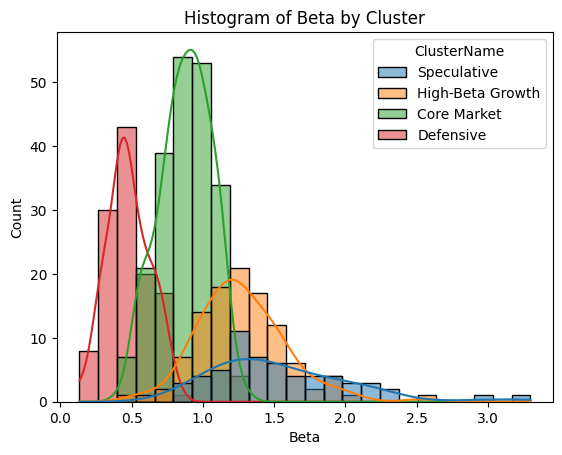

In [ ]:
fig, ax = plt.subplots()
sns.histplot(data=merged_df, x='Beta', hue='ClusterName', kde=True)
ax.set_title('Histogram of Beta by Cluster')
plt.show()

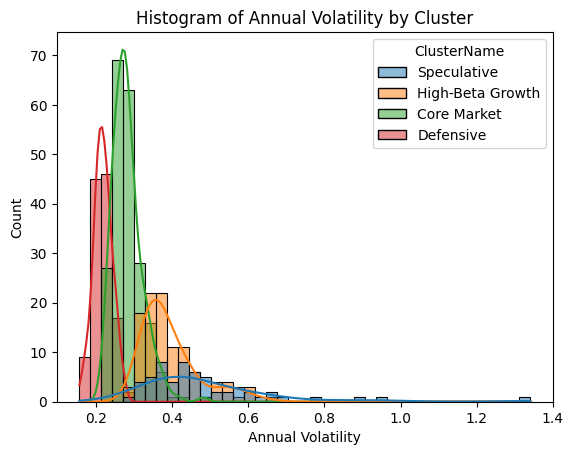

In [ ]:
fig, ax = plt.subplots()
sns.histplot(data=merged_df, x='Annual Volatility', hue='ClusterName', kde=True)
ax.set_title('Histogram of Annual Volatility by Cluster')
plt.show()

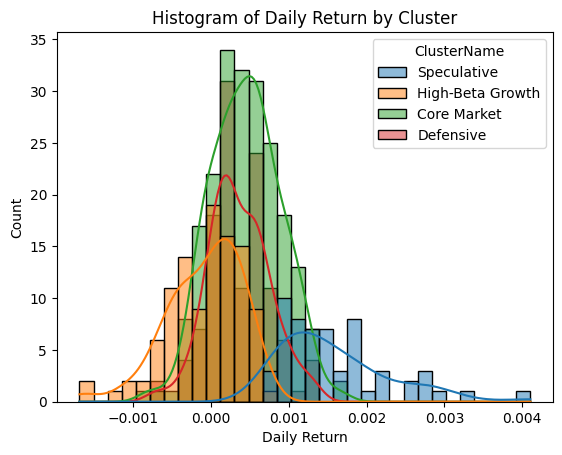

In [ ]:
fig, ax = plt.subplots()
sns.histplot(data=merged_df, x='Daily Return', hue='ClusterName', kde=True)
ax.set_title('Histogram of Daily Return by Cluster')
plt.show()

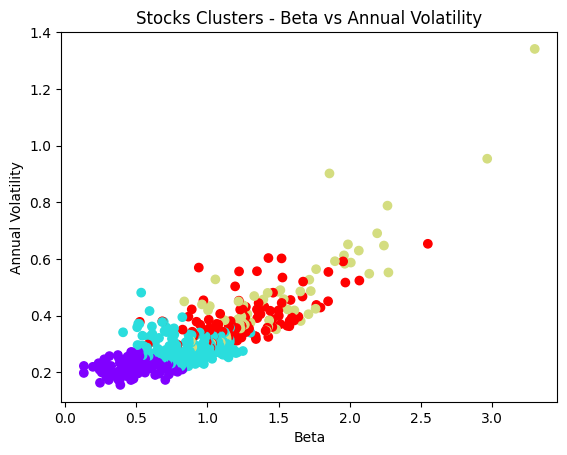

In [ ]:
plt.scatter(merged_df['Beta'], merged_df['Annual Volatility'],
            c=merged_df['KMeans_Cluster'], cmap='rainbow')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title('Stocks Clusters - Beta vs Annual Volatility')
plt.show()

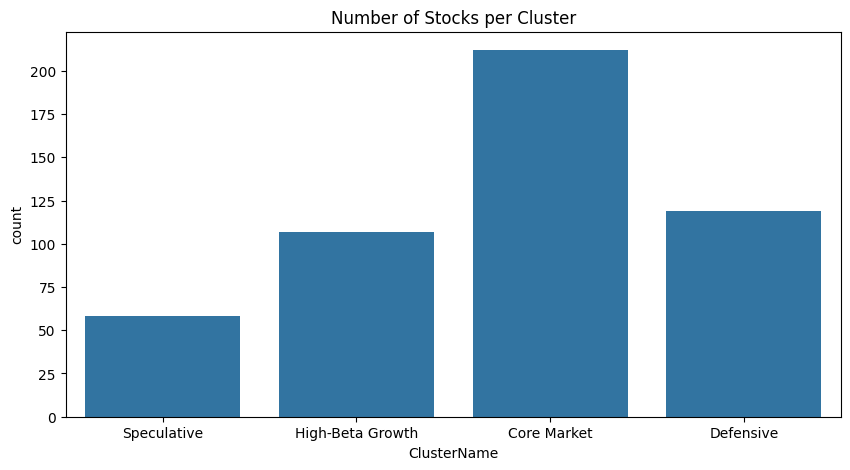

In [ ]:
f, ax = plt.subplots(figsize=(10, 5))
ax = sns.countplot(x='ClusterName', data=merged_df)
ax.set_title('Number of Stocks per Cluster')
plt.show()

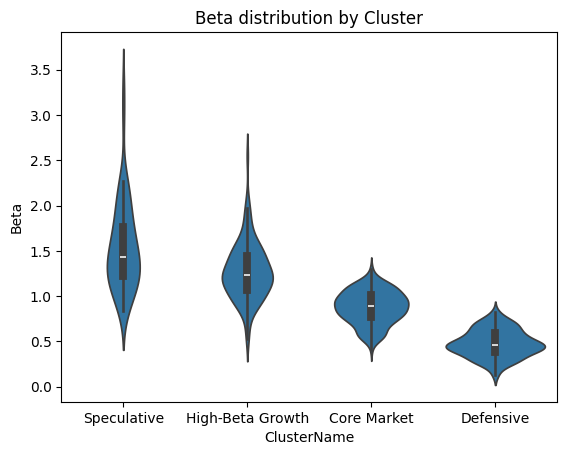

In [ ]:
sns.violinplot(x='ClusterName', y='Beta', data=merged_df)
plt.title('Beta distribution by Cluster')
plt.show()

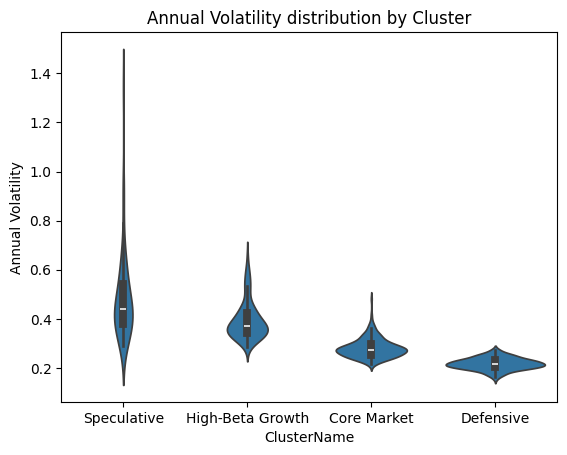

In [ ]:
sns.violinplot(x='ClusterName', y='Annual Volatility', data=merged_df)
plt.title('Annual Volatility distribution by Cluster')
plt.show()

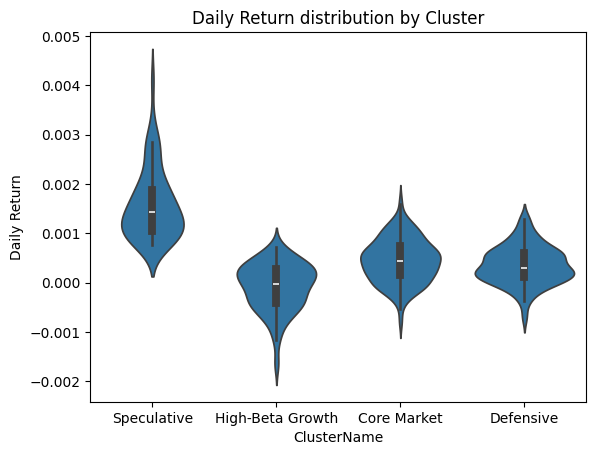

In [ ]:
sns.violinplot(x='ClusterName', y='Daily Return', data=merged_df)
plt.title('Daily Return distribution by Cluster')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy import stats

features = ['Beta', 'Annual Volatility', 'Daily Return']
X = merged_df[features].copy()

X_fix = pd.DataFrame()

X_fix['Beta'] = stats.boxcox(X['Beta'] - X['Beta'].min() + 1)[0]
X_fix['Annual Volatility'] = stats.boxcox(X['Annual Volatility'] - X['Annual Volatility'].min() + 1)[0]
X_fix['Daily Return'] = X['Daily Return'].values

scaler = StandardScaler()
scaler.fit(X_fix)
X_normalized = scaler.transform(X_fix)


df_normalized = pd.DataFrame(X_normalized, columns=features)
df_normalized['ID'] = merged_df['Ticker'].values
df_normalized['Cluster'] = merged_df['ClusterName'].values

df_nor_melt = pd.melt(df_normalized.reset_index(),
                      id_vars=['ID', 'Cluster'],
                      value_vars=features,
                      var_name='Attribute',
                      value_name='Value')
df_nor_melt.head()

,ID,Cluster,Attribute,Value
0,CVNA,Speculative,Beta,3.335179
1,COIN,Speculative,Beta,3.053433
2,XYZ,High-Beta Growth,Beta,2.652065
3,NVDA,Speculative,Beta,2.347917
4,APP,Speculative,Beta,2.340241


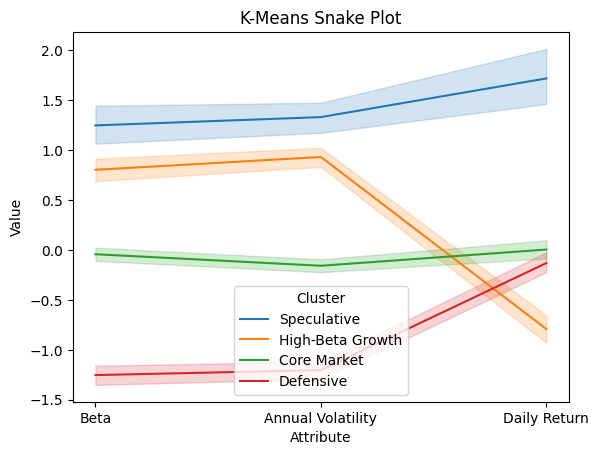

In [ ]:
sns.lineplot(x='Attribute', y='Value', hue='Cluster', data=df_nor_melt)
plt.title('K-Means Snake Plot')
plt.show()

In [ ]:

weights_dict = {'Defensive': 0.40,
                'Core Market': 0.30,
                'High-Beta Growth': 0.20,
                'Speculative': 0.10}


portfolio_list = []
for cname, weight in weights_dict.items():
    sub = merged_df[merged_df['ClusterName'] == cname].sort_values('Daily Return', ascending=False).head(5)
    sub = sub.copy()
    sub['Weight'] = weight / 5
    portfolio_list.append(sub)

portfolio = pd.concat(portfolio_list)
portfolio[['Ticker', 'ClusterName', 'Beta', 'Annual Volatility', 'Daily Return', 'Weight']]

,Ticker,ClusterName,Beta,Annual Volatility,Daily Return,Weight
452,CAH,Defensive,0.421337,0.234460,0.001293,0.08
440,PGR,Defensive,0.451923,0.256692,0.001284,0.08
381,WMB,Defensive,0.603022,0.229073,0.001253,0.08
483,MCK,Defensive,0.289305,0.233863,0.001237,0.08
358,BSX,Defensive,0.682378,0.217580,0.001063,0.08
404,TKO,Core Market,0.544408,0.329721,0.001671,0.06
392,LLY,Core Market,0.576462,0.287856,0.001592,0.06
275,NRG,Core Market,0.867740,0.334246,0.001343,0.06
173,GDDY,Core Market,1.052979,0.298462,0.001305,0.06
364,MPC,Core Market,0.661312,0.321914,0.001301,0.06


In [ ]:
weighted_beta = (portfolio['Beta'] * portfolio['Weight']).sum()
weighted_vol = (portfolio['Annual Volatility'] * portfolio['Weight']).sum()
weighted_ret = (portfolio['Daily Return'] * portfolio['Weight']).sum()

print('Portfolio-Weighted Beta:             ', round(weighted_beta, 4))
print('Portfolio-Weighted Annual Volatility:', round(weighted_vol, 4))
print('Portfolio-Weighted Daily Return:     ', round(weighted_ret, 6))

Portfolio-Weighted Beta:              0.9051
Portfolio-Weighted Annual Volatility: 0.3442
Portfolio-Weighted Daily Return:      0.001369


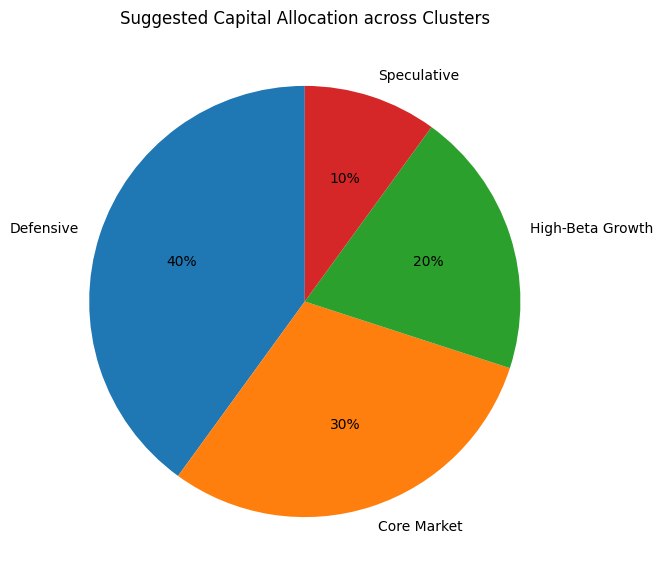

In [ ]:
alloc = pd.Series(weights_dict)
plt.figure(figsize=(7, 7))
plt.pie(alloc, labels=alloc.index, autopct='%1.0f%%', startangle=90)
plt.title('Suggested Capital Allocation across Clusters')
plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect('StockDM')
cur = conn.cursor()

In [ ]:
df_Stock = merged_df[['Ticker']].drop_duplicates().reset_index(drop=True)
df_Stock['Ticker_ID'] = df_Stock.index + 1
df_Stock = df_Stock[['Ticker_ID', 'Ticker']]
df_Stock.head()

,Ticker_ID,Ticker
0,1,CVNA
1,2,COIN
2,3,XYZ
3,4,NVDA
4,5,APP


In [ ]:
df_Cluster = merged_df[['ClusterName']].drop_duplicates().reset_index(drop=True)
df_Cluster['Cluster_ID'] = df_Cluster.index + 1

risk_band_map = {'Defensive': 'Low',
                 'Core Market': 'Medium',
                 'High-Beta Growth': 'High',
                 'Speculative': 'Very High'}
df_Cluster['Risk_Band'] = df_Cluster['ClusterName'].map(risk_band_map)
df_Cluster = df_Cluster[['Cluster_ID', 'ClusterName', 'Risk_Band']]
df_Cluster

,Cluster_ID,ClusterName,Risk_Band
0,1,Speculative,Very High
1,2,High-Beta Growth,High
2,3,Core Market,Medium
3,4,Defensive,Low


In [ ]:
df_Time = pd.DataFrame({
    'Time_ID': [1, 2, 3],
    'DateYear': [2022, 2023, 2024],
    'PeriodLabel': ['Year-2022', 'Year-2023', 'Year-2024']
})
df_Time

,Time_ID,DateYear,PeriodLabel
0,1,2022,Year-2022
1,2,2023,Year-2023
2,3,2024,Year-2024


In [ ]:
fact_rows = []
for _, row in merged_df.iterrows():
    ticker_id = df_Stock.loc[df_Stock['Ticker'] == row['Ticker'], 'Ticker_ID'].values[0]
    cluster_id = df_Cluster.loc[df_Cluster['ClusterName'] == row['ClusterName'], 'Cluster_ID'].values[0]
    for time_id in df_Time['Time_ID']:
        fact_rows.append({'Time_ID': time_id,
                          'Ticker_ID': ticker_id,
                          'Cluster_ID': cluster_id,
                          'Beta': row['Beta'],
                          'AnnualVolatility': row['Annual Volatility'],
                          'DailyReturn': row['Daily Return']})
df_Fact = pd.DataFrame(fact_rows)
df_Fact.head()

,Time_ID,Ticker_ID,Cluster_ID,Beta,AnnualVolatility,DailyReturn
0,1,1,1,3.298454,1.341039,0.003219
1,2,1,1,3.298454,1.341039,0.003219
2,3,1,1,3.298454,1.341039,0.003219
3,1,2,1,2.964902,0.953848,0.001768
4,2,2,1,2.964902,0.953848,0.001768


In [ ]:
df_Stock.to_sql('STOCK', conn, if_exists='replace', index=False)
df_Cluster.to_sql('CLUSTER', conn, if_exists='replace', index=False)
df_Time.to_sql('TIMEDIM', conn, if_exists='replace', index=False)
df_Fact.to_sql('STOCK_PERFORMANCE', conn, if_exists='replace', index=False)

check = pd.read_sql('SELECT * FROM STOCK_PERFORMANCE LIMIT 5', conn)
check

,Time_ID,Ticker_ID,Cluster_ID,Beta,AnnualVolatility,DailyReturn
0,1,1,1,3.298454,1.341039,0.003219
1,2,1,1,3.298454,1.341039,0.003219
2,3,1,1,3.298454,1.341039,0.003219
3,1,2,1,2.964902,0.953848,0.001768
4,2,2,1,2.964902,0.953848,0.001768


In [ ]:
Q1 = pd.read_sql('''
    SELECT C.ClusterName, C.Risk_Band,
           AVG(F.Beta) AS AvgBeta,
           AVG(F.AnnualVolatility) AS AvgVolatility,
           AVG(F.DailyReturn) AS AvgReturn,
           COUNT(DISTINCT F.Ticker_ID) AS NumStocks
    FROM STOCK_PERFORMANCE F
    INNER JOIN CLUSTER C ON F.Cluster_ID = C.Cluster_ID
    GROUP BY C.ClusterName, C.Risk_Band
    ORDER BY AvgBeta
''', conn)
Q1

,ClusterName,Risk_Band,AvgBeta,AvgVolatility,AvgReturn,NumStocks
0,Defensive,Low,0.477223,0.217614,0.000354,119
1,Core Market,Medium,0.878528,0.281771,0.000443,212
2,High-Beta Growth,High,1.272540,0.393354,-0.000086,107
3,Speculative,Very High,1.543203,0.485729,0.001581,58


In [ ]:
Q2 = pd.read_sql('''
    SELECT T.DateYear, C.ClusterName,
           AVG(F.Beta) AS AvgBeta,
           AVG(F.AnnualVolatility) AS AvgVolatility,
           AVG(F.DailyReturn) AS AvgReturn,
           DENSE_RANK() OVER (PARTITION BY T.DateYear ORDER BY AVG(F.DailyReturn) DESC) AS RankReturn
    FROM STOCK_PERFORMANCE F
    INNER JOIN CLUSTER C ON F.Cluster_ID = C.Cluster_ID
    INNER JOIN TIMEDIM T ON F.Time_ID = T.Time_ID
    GROUP BY T.DateYear, C.ClusterName
    ORDER BY T.DateYear, RankReturn
''', conn)
Q2

,DateYear,ClusterName,AvgBeta,AvgVolatility,AvgReturn,RankReturn
0,2022,Speculative,1.543203,0.485729,0.001581,1
1,2022,Core Market,0.878528,0.281771,0.000443,2
2,2022,Defensive,0.477223,0.217614,0.000354,3
3,2022,High-Beta Growth,1.272540,0.393354,-0.000086,4
4,2023,Speculative,1.543203,0.485729,0.001581,1
5,2023,Core Market,0.878528,0.281771,0.000443,2
6,2023,Defensive,0.477223,0.217614,0.000354,3
7,2023,High-Beta Growth,1.272540,0.393354,-0.000086,4
8,2024,Speculative,1.543203,0.485729,0.001581,1
9,2024,Core Market,0.878528,0.281771,0.000443,2


In [ ]:
Q3 = pd.read_sql('''
    SELECT S.Ticker, C.ClusterName,
           AVG(F.Beta) AS Beta,
           AVG(F.AnnualVolatility) AS Volatility,
           AVG(F.DailyReturn) AS Return
    FROM STOCK_PERFORMANCE F
    INNER JOIN STOCK S ON F.Ticker_ID = S.Ticker_ID
    INNER JOIN CLUSTER C ON F.Cluster_ID = C.Cluster_ID
    GROUP BY S.Ticker, C.ClusterName
    ORDER BY C.ClusterName, Return DESC
    LIMIT 40
''', conn)
Q3

,Ticker,ClusterName,Beta,Volatility,Return
0,TKO,Core Market,0.544408,0.329721,0.001671
1,LLY,Core Market,0.576462,0.287856,0.001592
2,NRG,Core Market,0.867740,0.334246,0.001343
3,GDDY,Core Market,1.052979,0.298462,0.001305
4,MPC,Core Market,0.661312,0.321914,0.001301
5,IBKR,Core Market,0.871252,0.304441,0.001289
6,IRM,Core Market,0.917736,0.287123,0.001276
7,ERIE,Core Market,0.574560,0.283445,0.001240
8,TDG,Core Market,1.090523,0.274050,0.001212
9,HUBB,Core Market,0.972085,0.292891,0.001184


In [ ]:
cur.execute('DROP VIEW IF EXISTS M1')
cur.execute('''
    CREATE VIEW M1 AS
    SELECT T.DateYear, C.ClusterName, C.Risk_Band,
           AVG(F.Beta) AS AvgBeta,
           AVG(F.AnnualVolatility) AS AvgVolatility,
           AVG(F.DailyReturn) AS AvgReturn,
           COUNT(DISTINCT F.Ticker_ID) AS NumStocks
    FROM STOCK_PERFORMANCE F
    INNER JOIN CLUSTER C ON F.Cluster_ID = C.Cluster_ID
    INNER JOIN TIMEDIM T ON F.Time_ID = T.Time_ID
    GROUP BY T.DateYear, C.ClusterName, C.Risk_Band
''')

m1 = pd.read_sql('SELECT * FROM M1', conn)
m1

,DateYear,ClusterName,Risk_Band,AvgBeta,AvgVolatility,AvgReturn,NumStocks
0,2022,Core Market,Medium,0.878528,0.281771,0.000443,212
1,2022,Defensive,Low,0.477223,0.217614,0.000354,119
2,2022,High-Beta Growth,High,1.272540,0.393354,-0.000086,107
3,2022,Speculative,Very High,1.543203,0.485729,0.001581,58
4,2023,Core Market,Medium,0.878528,0.281771,0.000443,212
5,2023,Defensive,Low,0.477223,0.217614,0.000354,119
6,2023,High-Beta Growth,High,1.272540,0.393354,-0.000086,107
7,2023,Speculative,Very High,1.543203,0.485729,0.001581,58
8,2024,Core Market,Medium,0.878528,0.281771,0.000443,212
9,2024,Defensive,Low,0.477223,0.217614,0.000354,119


In [ ]:
Q1_using_M1 = pd.read_sql('''
    SELECT ClusterName, Risk_Band,
           AVG(AvgBeta) AS AvgBeta,
           AVG(AvgVolatility) AS AvgVolatility,
           AVG(AvgReturn) AS AvgReturn
    FROM M1
    GROUP BY ClusterName, Risk_Band
    ORDER BY AvgBeta
''', conn)
Q1_using_M1

,ClusterName,Risk_Band,AvgBeta,AvgVolatility,AvgReturn
0,Defensive,Low,0.477223,0.217614,0.000354
1,Core Market,Medium,0.878528,0.281771,0.000443
2,High-Beta Growth,High,1.272540,0.393354,-0.000086
3,Speculative,Very High,1.543203,0.485729,0.001581


In [ ]:
Q2_using_M1 = pd.read_sql('''
    SELECT DateYear, ClusterName, AvgBeta, AvgVolatility, AvgReturn,
           DENSE_RANK() OVER (PARTITION BY DateYear ORDER BY AvgReturn DESC) AS RankReturn
    FROM M1
    ORDER BY DateYear, RankReturn
''', conn)
Q2_using_M1

,DateYear,ClusterName,AvgBeta,AvgVolatility,AvgReturn,RankReturn
0,2022,Speculative,1.543203,0.485729,0.001581,1
1,2022,Core Market,0.878528,0.281771,0.000443,2
2,2022,Defensive,0.477223,0.217614,0.000354,3
3,2022,High-Beta Growth,1.272540,0.393354,-0.000086,4
4,2023,Speculative,1.543203,0.485729,0.001581,1
5,2023,Core Market,0.878528,0.281771,0.000443,2
6,2023,Defensive,0.477223,0.217614,0.000354,3
7,2023,High-Beta Growth,1.272540,0.393354,-0.000086,4
8,2024,Speculative,1.543203,0.485729,0.001581,1
9,2024,Core Market,0.878528,0.281771,0.000443,2


In [ ]:
merged_df.to_csv('partC_named_clusters.csv', index=False)
portfolio.to_csv('partC_suggested_portfolio.csv', index=False)
print('Saved partC_named_clusters.csv and partC_suggested_portfolio.csv')

Saved partC_named_clusters.csv and partC_suggested_portfolio.csv
